In [1]:
%matplotlib inline

# X-ray absorption spectroscopy simulation in the time domain

What will be the first industrially useful quantum algorithm to run on
fault-tolerant quantum computers? Answering this question is the main
mission of the Xanadu algorithms team, as the company races to \"build
quantum computers that are useful and available to people everywhere\".
As logical qubits will likely be a scarce resource for a while, we
expect that our best chance at finding quantum advantage lies in
simulating dynamics of *small* but *highly correlated* quantum systems.
One such application is simulating [X-ray absorption
spectroscopy](https://en.wikipedia.org/wiki/X-ray_absorption_spectroscopy)
(XAS), which can be useful in workflows for identifying structural
degradation mechanisms in material candidates for battery designs 🔋.
Here, the ultralocal nature of X-ray absorption naturally leads to only
needing to simulate small clusters, while the strong correlations
inherent in excited states probed by XAS make the simulation challenging
for classical computers. This demo will show you how to implement an
optimized simulation algorithm developed in the paper ["Fast simulations
of X-ray absorption spectroscopy for battery materials on a quantum
computer"](https://arxiv.org/abs/2506.15784) in PennyLane.

First, we will discuss why simulating X-ray absorption spectroscopy is a
promising application for quantum computers. Then we will explain the
main steps in the simulation algorithm and how to implement a simplified
version in PennyLane.

> Prerequisite understanding
>
> We will be using concepts that were introduced in other PennyLane
> demos, such as [Using PennyLane with PySCF and
> OpenFermion](https://pennylane.ai/qml/demos/tutorial_qchem_external),
> [Initial state preparation for quantum
> chemistry](https://pennylane.ai/qml/demos/tutorial_initial_state_preparation),
> and [How to build compressed double-factorized
> Hamiltonians](https://pennylane.ai/qml/demos/tutorial_how_to_build_compressed_double_factorized_hamiltonians).
> If you haven't checked out those demos yet, it might be best to do so
> and then come back here 🔙.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/OGthumbnail_xas.png' alt='' style='display:block; margin:auto; width:50%;'/>
</figure>

## Why simulate X-ray absorption spectroscopy?

Lithium-excess materials are transition metal oxides that are promising
candidates for next-generation battery cathodes. Engineered to
accommodate extra lithium atoms in their lattice structure, these
materials could potentially double the energy densities in battery
designs. However, prototype Li-excess cathodes rapidly degrade after
only a handful of charge-discharge cycles. The mechanism of this
degradation is still poorly understood, making it challenging for
researchers to resolve it. Knowledge of the internal electronic bonding
and oxidation states of degraded cathodes is crucial to solving this
mystery. This bonding can be examined using X-ray absorption
spectroscopy, which directly probes local structure by exciting tightly
bound core electrons. The actual degraded structures that arise during
cycling can then be identified by a process known as "spectral
fingerprinting", where reference spectra of small molecular clusters are
matched to the experimental spectrum. A fast method of simulating
reference spectra for use in fingerprinting would be a crucial component
in an iterative workflow for identifying promising cathode materials.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/fingerprinting.gif' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 1: <em>How simulation of X-ray absorption spectra can
enable identification of oxidation states in candidate battery
materials.</em> Spectral fingerprinting can be used to identify
constituent structures of a material by matching experimental spectra
with simulated spectra.</figcaption>
</figure>

Simulating these spectra is a difficult task for classical computers \--
the highly correlated excited states are hard to compute classically,
particularly for clusters containing transition metals. However, the low
number of qubits needed to simulate the electronic orbitals in these
small clusters make this calculation well suited for quantum computers,
which can naturally handle the large amount of correlations in the
electronic state. Tasks like this are promising candidates for quantum
advantage \-- simulations of *small* but *highly correlated* systems.

## Algorithm

Simulating reference spectra requires calculating the observable of the
experiment, which in this case is the [absorption cross
section](https://en.wikipedia.org/wiki/Absorption_cross_section). We
will describe this quantity below and then explain how a *time-domain*
simulation algorithm can estimate it.

### Observable: absorption cross section

In XAS experiments, the absorption cross section $\sigma_A$ as a
function of the incident X-ray frequency $\omega$ is measured for a
given material. This is proportional to the rate of absorption of X-ray
photons of various energies. For our situation, the electrons in the
molecular cluster start in a ground molecular state $|I\rangle$ with
energy $E_I$. This ground state will be excited to states $|F\rangle$
with energies $E_F$ by the radiative field through the action of the
dipole operator $\hat m_\rho,$ where $\rho$ is any of the Cartesian
directions $x,\ y,\,$ or $z$.

The absorption cross section is given by the equation

$$\sigma_A(\omega) = \frac{4 \pi}{3 \hbar c} \omega \sum_{F \neq I}\sum_{\rho=x,y,z} \frac{|\langle F|\hat m_\rho|I \rangle|^2 \eta}{((E_F - E_I)-\omega)^2 + \eta^2}\,,$$

where $c$ is the speed of light, $\hbar$ is Planck's constant, and
$\eta$ is the line broadening, set to match the experimental resolution
of the spectroscopy. Below is an illustration of an X-ray absorption
spectrum.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/example_spectrum.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 2: <em>Example X-ray absorption spectrum.</em>
Illustration of how the peak positions <span
class="math inline"><em>E</em><sub><em>F</em></sub> − <em>E</em><sub><em>i</em></sub></span>,
amplitudes <span
class="math inline">|⟨<em>F</em>|<em>m̂</em><sub><em>ρ</em></sub>|<em>I</em>⟩|<sup>2</sup></span>
and width <span class="math inline"><em>η</em></span> determine the
spectrum.</figcaption>
</figure>

The goal of this demo is to implement a quantum algorithm that can
calculate this spectrum.

### Time-domain simulation

Both the initial state $|I\rangle$ and the dipole operator acting on the
initial state $\hat m_\rho|I\rangle$ can be determined classically, and
we'll demonstrate how to do that later. With the initial state computed,
we will use a mathematical trick called a *frequency-domain* [Green's
function](https://en.wikipedia.org/wiki/Green%27s_function) to re-write
the absorption cross section as an expectation value of a specific
operator. We can write the cross section as the imaginary part of the
following Green's function (see Section IIB in Ref.)

$$\mathcal{G}_\rho(\omega) = \langle I|\hat m_\rho \frac{1}{\hat H -E_I -\omega +i\eta} \hat m_\rho |I\rangle\,.$$

With a bit of algebra, we can confirm that this works: inserting a
resolution of identity of final states $\sum_F |F\rangle \langle F|$ and
simplifying gives

$$\mathrm{Im}\,\mathcal{G}_\rho(\omega) = -\sum_{F\neq I} \frac{|\langle F|\hat m_\rho|I\rangle|^2\eta}{(E_F- E_I -\omega)^2 +\eta^2} - \frac{|\langle I|\hat m_\rho|I\rangle|^2\eta}{\omega^2 +\eta^2}\,,$$

where the first term is proportional to the absorption cross section.
The second term is zero if we centre the frame of reference for our
molecular orbitals at the nuclear-charge weighted centre for our
molecular cluster of choice.

Okay, so how do we determine $\mathcal{G}_\rho(\omega)$? If we are going
to evaluate this quantity in a quantum register, it will need to be
normalized, so instead we are looking for

$$G_\rho(\omega) = \eta \frac{\mathcal{G}_\rho(\omega)}{||\hat m_\rho | I \rangle ||^2} \,.$$

Calculating this quantity directly is expensive. We need to invert the
Hamiltonian matrix, which is hard as it typically requires using
linear-solve algorithms like HHL. We would also need to calculate the
cross section at every frequency, which can quickly run up the cost.
Instead, our algorithm will aim to simulate the dynamics of our initial
state in the *time domain*, and then [Fourier
transform](https://en.wikipedia.org/wiki/Fourier_transform) the results
classically to obtain the frequency spectrum! This allows us to
construct the entire spectrum *at once*, rather than tediously measure
each individual frequency we are interested in. This is especially
important if the number of excited states underlying the absorption
spectrum is very large, which we expect to be the case for moderately
sized clusters.

The time-domain Green's function $\tilde G(t_j)$ can be determined using
the expectation value of the time-evolution operator (normalized) at
times $t_j = \tau j$, where $\tau$ is the time step and $j$ is the
time-step index

$$\tilde G_\rho(t_j) = \frac{\langle I|\hat m _\rho e^{- i\hat H t_j} \hat m_\rho |I\rangle}{|| \hat m_\rho |I\rangle ||^2}\,.$$

This quantity can easily be calculated on a quantum computer! We can use
a [Hadamard test](https://en.wikipedia.org/wiki/Hadamard_test) circuit
with the unitary of time evolution to measure the expectation value for
each time $t_j$.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/global_circuit.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 3: <em>Circuit for XAS simulation</em>. The algorithm
is ultimately a Hadamard test circuit, and we divide it into three
components.</figcaption>
</figure>

Repeating this test a number of times $N$ and taking the mean of the
results gives an estimate for $G_\rho(t_j)$. The spectrum can then be
obtained with a discrete time-domain Fourier transform

$$-\mathrm{Im}\,G_\rho(\omega) = \frac{\eta\tau}{2\pi} \sum_{j=-\infty}^\infty e^{-\eta |t_j|} \tilde G(t_j) e^{i\omega t_j}\,.$$

The time step $\tau \sim \mathcal{O}(||\hat H||^{-1})$ should be small
enough to resolve the largest frequency components that we are
interested in, which correspond to the final states with the largest
energy. In practice, this is not the largest eigenvalue of $\hat H$, but
simply the largest energy we want to show in the spectrum.

The circuit we will construct to determine the expectation values is
shown above. It has three main components:

-   **State prep**, the state $\hat m_\rho |I\rangle$ is prepared in the
    quantum register, and an auxiliary qubit is prepared to control the
    time evolution.
-   **Time evolution**, the state is evolved under the electronic
    Hamiltonian.
-   **Measurement**, the time-evolved state is measured to obtain
    statistics for the expectation value.

Let's look at how to implement these steps in PennyLane. We will make
use of the
[-](https://docs.pennylane.ai/en/stable/code/qml_qchem.html#module-)
module, as well as initial state preparation methods from
[PySCF](https://pyscf.org/).

## State preparation

We need to classically determine the ground state $|I\rangle$, and the
dipole operator's action on that state $\hat m_\rho |I\rangle$. For
complicated molecular clusters, it\'s common to choose and consider only
a subset of molecular orbitals and electrons in a calculation. This set
of orbitals and electrons is known as the "active space". Utilizing an
active space reduces the cost of performing calculations on complicated
molecular instances, while still preserving the interesting features of
the molecule\'s behaviour. For this demo, our calculation will obtain
the spectrum of the $\mathrm{N}_2$ molecule with a small active space.
While the molecule used here is quite simple, the method demonstrated
below will work for more complicated molecules. For simplicity, in this
demo we target the low-lying excited state spectrum rather than the
X-ray portion of it, but the algorithm works exactly the same for the
XAS signal \-- we just need to implement the core-valence separation
approximation (see the Appendix).

### Ground state calculation

If you haven't, check out the demo [Initial state preparation for
quantum
chemistry](https://pennylane.ai/qml/demos/tutorial_initial_state_preparation).
We will be expanding on that demo with code to import a state from the
[complete active space configuration
interaction](https://pyscf.org/user/mcscf.html) (CASCI) methods of
PySCF, where we restrict the set of active orbitals used in the
calculation.

We start by creating our molecule object using the [Gaussian type
orbitals](https://en.wikipedia.org/wiki/Gaussian_orbital) module
`pyscf.gto`, and obtaining the Hartree-Fock molecular orbitals with the
[self-consistent field methods](https://pyscf.org/user/scf.html)
`pyscf.scf`.


In [2]:
from pyscf import gto, scf
import numpy as np

# Create a Mole object.
r = 1.0  # Bond length in Angstrom.
symbols = ["N", "N"]
geometry = np.array([[0.0, 0.0, -r / 2], [0.0, 0.0, r / 2]])
mol = gto.Mole(atom=zip(symbols, geometry), basis="sto3g", symmetry=None)
mol.build(verbose=0)

# Get the molecular orbitals.
hf = scf.RHF(mol)
hf.run(verbose=0)

Since we will be using PennyLane for other aspects of this calculation,
we want to make sure the molecular orbital coefficients are consistent
between our PennyLane and PySCF calculations. To do this, we can obtain
the molecular orbital coefficients from PennyLane using
[scf](https://docs.pennylane.ai/en/stable/code/api/pennylane.qchem.scf.html#),
and change the coefficients in the `hf` instance to match.


In [3]:
import pennylane as qml

mole = qml.qchem.Molecule(symbols, geometry, basis_name="sto-3g", unit="angstrom")

# Run self-consistent fields method to get molecular orbital coefficients.
_, coeffs, _, _, _ = qml.qchem.scf(mole)()

# Change MO coefficients in hf object to PennyLane calculated values.
hf.mo_coeff = coeffs

Next, let's define the active space we will use for our calculation.
This will be the number of orbitals $n_\mathrm{cas}$ and the number of
electrons. For $\mathrm{N}_2$, we will use an active space of five
orbitals and four electrons. Running a `CASCI` instance allows us to
calculate the ground state of our system with this selected active
space. The `CASCI` method in PySCF is equivalent to a
[full-configuration
interaction](https://en.wikipedia.org/wiki/Full_configuration_interaction)
(FCI) procedure on a subset of molecular orbitals.


In [4]:
from pyscf import mcscf

# Define active space of (orbitals, electrons).
n_cas, n_electron_cas = (5, 4)

# Number of core (non-active) orbitals.
n_core = (mol.nelectron - n_electron_cas) // 2  

# Initialize CASCI instance of N2 molecule as mycasci.
mycasci = mcscf.CASCI(hf, ncas=n_cas, nelecas=n_electron_cas)
mycasci.run(verbose=0)

# Calculate ground state, and omit small state components.
casci_state = mycasci.ci
casci_state[abs(casci_state) < 1e-6] = 0

To implement this state as a PennyLane state vector, we need to convert
the `casci_state` into a format that is easy to import into PennyLane.
One way to do this is to use a sparse matrix representation to turn
`casci_state` into a dictionary, and then use
[import_state](pennylane.qchem.convert.import_state) to import into
PennyLane. Here is how you can turn a full-configuration interaction
matrix like `casci_state` into a dictionary.


In [5]:
from scipy.sparse import coo_matrix
from pyscf.fci.cistring import addrs2str

# Convert casci_state into a sparse matrix.
sparse_cascimatr = coo_matrix(casci_state, shape=np.shape(mycasci.ci), dtype=float)
row, col, dat = sparse_cascimatr.row, sparse_cascimatr.col, sparse_cascimatr.data

# Turn indices into strings.
n_cas_a = mycasci.ncas  # Number of alpha spin orbitals.
n_cas_b = n_cas_a  # Number of beta spin orbitals.
n_electron_cas_a, n_electron_cas_b = mycasci.nelecas

strs_row = addrs2str(n_cas_a, n_electron_cas_a, row)
strs_col = addrs2str(n_cas_b, n_electron_cas_b, col)

# Create the FCI matrix as a dict.
wf_casci_dict = dict(zip(list(zip(strs_row, strs_col)), dat))

Lastly, we will use the helper function
[\_sign_chem_to_phys](pennylane.qchem.convert._sign_chem_to_phys) to
adjust the sign of state components to match what they should be for the
PennyLane orbital occupation number ordering. Then, we can import the
state into PennyLane using
[\_wfdict_to_statevector](pennylane.qchem.convert._wfdict_to_statevector).

> Chemists\' and physicists\' notation for ordering spin orbitals
>
> In general, states from computation chemistry workflows will have spin
> orbitals ordered in chemists\' notation, such that all of one spin is
> on the left, and the other on the right. PennyLane uses the
> physicists\' notation, where the spatial orbitals are ordered, and the
> spins alternate up and down. When changing a state from one convention
> to the next, the sign of some state amplitudes need to change to
> adhere to the fermionic anticommutation rules. The helper function
> [\_sign_chem_to_phys](pennylane.qchem.convert._sign_chem_to_phys) does
> this sign adjustment for us.


In [6]:
from pennylane.qchem.convert import _sign_chem_to_phys, _wfdict_to_statevector

wf_casci_dict = _sign_chem_to_phys(wf_casci_dict, n_cas)

# Convert dictionary to Pennylane state vector.
wf_casci = _wfdict_to_statevector(wf_casci_dict, n_cas)

# Dipole operator action

The electromagnetic field of the incident X-rays can excite the
electronic state through the [dipole
operator](https://en.wikipedia.org/wiki/Transition_dipole_moment). The
action of this operator is implemented in PennyLane as
[dipole_moment](https://docs.pennylane.ai/en/stable/code/api/pennylane.qchem.dipole_moment.html#).
We can calculate that operator, convert it to a matrix, and apply it to
our initial state $|I\rangle$ to obtain $\hat m_\rho|I\rangle$.

To generate this operator, we have to specify which molecular orbitals
are in our active space. We can obtain the indices of the included and
excluded orbitals using
[active_space](https://docs.pennylane.ai/en/stable/code/api/pennylane.qchem.active_space.html#)
to obtain the lists `active` and `core`, respectively.

The action of the dipole operator will be split into the three cartesian
directions $x,\ y$ and $z$, which we will loop over to obtain the states
$\hat m_{\{x,y,z\}}|I\rangle$. This will give us an operator that
describes general absorption of electro-magnetic radiation for our
molecule, including for energies outside of the XAS regime. This is fine
for our simple example, but for more complex instances you may want to
modify the dipole operator to restrict the final states (see the
Appendix for more details).


In [7]:
# Get core and active orbital indices.
core, active = qml.qchem.active_space(
    mole.n_electrons, mole.n_orbitals, 
    active_electrons=n_electron_cas, 
    active_orbitals=n_cas
)

m_rho = qml.qchem.dipole_moment(mole, cutoff=1e-8, core=core, active=active)()
rhos = range(len(m_rho))  # [0, 1, 2] are [x, y, z].

wf_dipole = []
dipole_norm = []

# Loop over cartesian coordinates and calculate m_rho|I>.
for rho in rhos:
    dipole_matrix_rho = qml.matrix(m_rho[rho], wire_order=range(2 * n_cas))
    wf = dipole_matrix_rho.dot(wf_casci)  # Multiply state into dipole matrix.

    if np.allclose(wf, np.zeros_like(wf)):  # If wf is zero, then set norm as zero.
        wf_dipole.append(wf)
        dipole_norm.append(0)

    else:  # Normalize the wavefunction.
        dipole_norm.append(np.linalg.norm(wf))
        wf_dipole.append(wf / dipole_norm[rho])

> Caution! Wire ordering
>
> When converting the operator `m_rho` to the matrix
> `dipole_matrix_rho`, the full set of wires needs to be specified,
> otherwise the matrix may not have the right dimension (if, for
> example, the operator is zero along any cartesian direction).

Let's prepare the circuit that will initialize our qubit register with
this state. We will need $2 n_\mathrm{cas}$ wires, which is twice the
number of orbitals in our active space, since we need to account for
spin. We will also add one auxiliary wire for the measurement circuit,
which we will prepare as the 0 wire with an applied Hadamard gate.


In [8]:
device_type = "lightning.qubit"
dev_prop = qml.device(device_type, wires=int(2*n_cas) + 1)


@qml.qnode(dev_prop)
def initial_circuit(wf):
    """Circuit to load initial state and prepare auxiliary qubit."""
    qml.StatePrep(wf, wires=dev_prop.wires.tolist()[1:])
    qml.Hadamard(wires=0)
    return qml.state()

> > Note
>
> To guarantee that $\langle I|\hat m_\rho|I\rangle$ is zero, we require
> that the `Mole` object's nuclear-charge-weighted centre is at the
> origin. This is true from our construction, since the geometry was
> defined to be symmetric about the origin, but we want to emphasize the
> importance of this condition.

# Time Evolution

Next we will discuss how to prepare the electronic Hamiltonian for
efficient time evolution in the Hadamard test circuit. We will perform
compressed double factorization (CDF) on the Hamiltonian to approximate
it as a series of fragments, each of which can be fast-forwarded in a
Trotter product formula.

If you haven't yet, go read the demo [How to build compressed
double-factorized
Hamiltonians](https://pennylane.ai/qml/demos/tutorial_how_to_build_compressed_double_factorized_hamiltonians),
because that is exactly what we are going to do! You could also look at
Section III in Ref..

## Electronic Hamiltonian

Our electronic Hamiltonian is

$$H = E + \sum_{p,q=1}^N \sum_{\gamma\in\{\uparrow,\downarrow\}} (p|\kappa|q) a^\dagger_{p\gamma}a_{q\gamma} + \frac12 \sum_{p,q,r,s=1}^N\sum_{\gamma,\beta\in\{\uparrow,\downarrow\}} (pq|rs) a^\dagger_{p\gamma}a_{q\gamma} a^\dagger_{r\beta}a_{s\beta} \,,$$

where $a^{(\dagger)}_{p\gamma}$ is the annihilation (creation) operator
for a molecular orbital $p$ with spin $\gamma$, $E$ is the nuclear core
constant, $N$ is the number of spatial orbitals, and $(p|\kappa|q)$ and
$(pq|rs)$ are the one- and two-electron integrals, respectively.

The core constant and the one- and two-electron integrals can be
computed in PennyLane using
[electron_integrals](https://docs.pennylane.ai/en/stable/code/api/pennylane.qchem.electron_integrals.html#).


In [9]:
core_constant, one, two = qml.qchem.electron_integrals(mole, core=core, active=active)()
core_constant = core_constant[0]

We will have to convert these to chemists\' notation.


In [10]:
two_chemist = qml.math.einsum("prsq->pqrs", two)
one_chemist = one - qml.math.einsum("pqrr->pq", two) / 2.0

Next, we will perform compressed double factorization of the
Hamiltonian\'s two-electron integrals to approximate them as a sum of
$L$ fragments

$$(pq|rs) \approx \sum_{\ell=1}^L \sum_{k, m=1}^N U_{pk}^{(\ell)}U_{qk}^{(\ell)}Z_{km}^{(\ell)}U_{rm}^{(\ell)}U_{sm}^{(\ell)}\,,$$

where $Z^{(\ell)}$ is symmetric and $U^{(\ell)}$ is orthogonal. These
matrices can be calculated using PennyLane's
[factorize](https://docs.pennylane.ai/en/stable/code/api/pennylane.qchem.factorize.html#)
function, with `compressed=True`. By default, $L$ is set as twice the
number of orbitals in our active space. The `Z` and `U` output here are
arrays of $L$ fragment matrices with dimension
$n_\mathrm{cas} \times n_\mathrm{cas}$.


In [11]:
from jax import config

config.update("jax_enable_x64", True)  # Required for factorize consistency.

# Factorize Hamiltonian, producing matrices Z and U for each fragment.
_, Z, U = qml.qchem.factorize(two_chemist, compressed=True)

print("Shape of the factors: ")
print("two_chemist", two_chemist.shape)
print("U", U.shape)
print("Z", Z.shape)

# Compare factorized two-electron fragment sum to the original.
approx_two_chemist = qml.math.einsum("tpk,tqk,tkl,trl,tsl->pqrs", U, U, Z, U, U)
assert qml.math.allclose(approx_two_chemist, two_chemist, atol=0.1)

Shape of the factors: 
two_chemist (5, 5, 5, 5)
U (10, 5, 5)
Z (10, 5, 5)


Note there are some terms in this decomposition of the two-electron
integrals that are exactly diagonalizable, and can be combined with the
one-electron integrals to simplify how the Hamiltonian time evolution is
implemented. We call these the "one-electron extra" terms and add them
to the one-electron integrals. We can then diagonalize their sum into
the matrix $Z^{(0)}$ with basis rotation matrix $U^{(0)}$ using
`np.linalg.eigh`, for easy implementation in the simulation circuit.


In [12]:
# Calculate the one-electron extra terms.
Z_prime = np.stack([np.diag(np.sum(Z[i], axis=-1)) for i in range(Z.shape[0])], axis=0)
one_electron_extra = qml.math.einsum("tpk,tkk,tqk->pq", U, Z_prime, U)

# Diagonalize the one-electron integral matrix while adding the one-electron extra.
eigenvals, U0 = np.linalg.eigh(one_chemist + one_electron_extra)
Z0 = np.diag(eigenvals)

# Constructing the time-propagation circuit

The main work of our algorithm will be to implement the time evolution
of the Hamiltonian fragments by using a Trotter product formula.

The trick when time evolving a compressed double-factorized Hamiltonian
is to use [Thouless's
theorem](https://joshuagoings.com/assets/Thouless_theorem.pdf) to
construct a size $2^{n_\mathrm{cas}} \times 2^{n_\mathrm{cas}}$ unitary
${\bf U}^{(\ell)}$ that is induced by a the single-particle basis
transformation $U^{(\ell)}$ (of size
$n_\mathrm{cas} \times n_\mathrm{cas}$). The Jordan-Wigner transform can
then turn the number operators $a^\dagger_p a_p = n_{p}$ into Pauli $Z$
rotations, via $n_p = (1-\sigma_{z,p})/2$. Note the $1/2$ term will
affect the global phase, and we will have to keep track of that
carefully. The resulting Hamiltonian looks like the following (for a
derivation see Appendix A of Ref.)

$$\begin{aligned}
H_\mathrm{CDF} &= \left(E + \sum_k Z_k^{(0)} - \frac12 \sum_{\ell, kj} Z_{kj}^{(\ell)} + \frac14 \sum_{\ell,k} Z_{kk}^{(\ell)} \right) {\bf 1} \\
&- \frac12 {\bf U}^{(0)} \left[ \sum_k Z_k^{(0)} \sum_\gamma \sigma_{z, k\gamma} \right] ({\bf U}^{(0)})^{T} \\ 
&+ \frac18 \sum_\ell {\bf U}^{(\ell)} \left[\sum_{(k, \gamma)\neq(j, \beta)} \left(Z_{kj}^{(\ell)}\sigma_{z, k\gamma}\sigma_{z, j\beta}\right)\right]({\bf U}^{(\ell)})^T\,.
\end{aligned}$$

The first term is a sum of the core constant and constant factors that
arise from the Jordan-Wigner transform and is just a global phase. The
second and third terms are the one- and two-electron fragments,
respectively. Below is an illustration of the circuit we will use to
implement the one- and two-electron fragments in a time-evolution of the
factorized Hamiltonian.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/UZU_circuits.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 4: One- and two-electron fragment implementations in
the time-evolution circuit (ignoring global phases). Basis rotations are
applied to both spin sections of the register.</figcaption>
</figure>

We can use
[BasisRotation](https://docs.pennylane.ai/en/stable/code/api/pennylane.BasisRotation.html#)
to generate a [Givens decomposition](demos/tutorial_givens_rotations)
for the large unitary ${\bf U}^{(\ell)}$ that is generated by the
single-particle basis rotation $U^{(\ell)}$ via Thouless\' theorem. Note
that we can do this separately for both spin-halves of the register,
since our Hamiltonian does not mix spin sectors: this is cheaper than
having one large unitary for the entire register.


In [13]:
def U_rotations(U, control_wires):
    """Circuit implementing the basis rotations of the Hamiltonian fragments."""
    U_spin = qml.math.kron(U, qml.math.eye(2))  # Apply to both spins.
    qml.BasisRotation(
        unitary_matrix=U_spin, wires=[int(i + control_wires) for i in range(2 * n_cas)]
    )

Next we write a function to perform the Z rotations. Controlled
arbitrary-angle rotations are expensive. To reduce the cost of having to
implement many controlled Z rotations at angles determined by the
matrices $Z^{(\ell)}$, we instead implement *uncontrolled* Z rotations
sandwiched by CNOT gates.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/double_phase_trick.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 5: Double-phase trick to decompose expensive
controlled-Z rotations into an uncontrolled-Z rotation sandwiched by
CNOT gates.</figcaption>
</figure>

For the one-electron terms, we loop over both the spin and orbital
indices, and apply the Z rotations using this double-phase trick. The
two-electron fragments are implemented the same way, except the
two-qubit rotations use
[MultiRZ](https://docs.pennylane.ai/en/stable/code/api/pennylane.MultiRZ.html#).
Notice that this is also where we keep track of part of the global phase
from the constant term in the Hamiltonian.


In [14]:
from itertools import product


def Z_rotations(Z, step, is_one_electron_term, control_wires):
    """Circuit implementing the Z rotations of the Hamiltonian fragments."""
    if is_one_electron_term:
        for sigma in range(2):
            for i in range(n_cas):
                qml.ctrl(
                    qml.X(wires=int(2*i + sigma + control_wires)),
                    control=range(control_wires),
                    control_values=0,
                )
                qml.RZ(-Z[i, i] * step / 2, wires=int(2*i + sigma + control_wires))
                qml.ctrl(
                    qml.X(wires=int(2*i + sigma + control_wires)),
                    control=range(control_wires),
                    control_values=0,
                )
        globalphase = np.sum(Z) * step  # Phase from 1/2 term in Jordan-Wigner transform.

    else:  # It's a two-electron fragment.
        for sigma, tau in product(range(2), repeat=2):
            for i, k in product(range(n_cas), repeat=2):
                if i != k or sigma != tau:  # Skip the one-electron correction terms.
                    qml.ctrl(qml.X(wires=int(2*i + sigma + control_wires)),
                            control=range(control_wires), control_values=0)
                    qml.MultiRZ(Z[i, k] / 8.0 * step,
                        wires=[int(2*i + sigma + control_wires),
                               int(2*k + tau + control_wires)])
                    qml.ctrl(qml.X(wires=int(2 * i + sigma + control_wires)),
                        control=range(control_wires), control_values=0)
        globalphase = np.trace(Z)/4.0*step - np.sum(Z)*step/2.0

    qml.PhaseShift(-globalphase, wires=0)

For the factorized Hamiltonian $H_\mathrm{CDF} = \sum_j^N H_j$, with
non-commuting fragments $H_j$, a second-order product formula
approximates the time evolution for a time step $\tau$ as

$$e^{-i\sum_j H_j \tau} \approx \prod_{j=1}^N e^{-i \frac{\tau}{2}H_j} \prod_{j=N}^1 e^{-i \frac{\tau}{2}H_j}\,.$$

Note in the formula above, the second product of time-evolution
fragments is reversed in order. The function `first_order_trotter` will
implement the $U$ rotations and $Z$ rotations, and adjust the global
phase from the core constant term. It will also be able to reverse the
order of applied fragments so we can later construct the second-order
Trotter step. Finally, we can further reduce cost by tracking the last
$U$ rotation used: that way we can implement two consecutive rotations
at once as $V^{(\ell)} = U^{(\ell-1)}(U^{(\ell)})^T$, halving the number
of rotations required per Trotter step.


In [15]:
def first_order_trotter(step, prior_U, final_rotation, reverse=False):
    """Implements a Trotter step for the CDF Hamiltonian."""
    # Prepend the one-electron fragment to the two-electron fragment array.
    _U0 = np.expand_dims(U0, axis=0)
    _Z0 = np.expand_dims(Z0, axis=0)
    _U = np.concatenate((_U0, U), axis=0)
    _Z = np.concatenate((_Z0, Z), axis=0)

    num_two_electron_fragments = U.shape[0]  # Number of fragments L.
    is_one_body = np.array([True] + [False] * num_two_electron_fragments)
    order = list(range(len(_Z)))

    if reverse:
        order = order[::-1]

    for fragment in order:
        U_rotations(prior_U @ _U[fragment], 1)
        Z_rotations(_Z[fragment], step, is_one_body[fragment], 1)
        prior_U = _U[fragment].T

    if final_rotation:
        U_rotations(prior_U, 1)

    # Global phase adjustment from core constant.
    qml.PhaseShift(-core_constant * step, wires=0)

    return prior_U

Our function `second_order_trotter` implements a second-order Trotter
step, returning a
[QNode](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html#).
The returned circuit applies
[StatePrep](https://docs.pennylane.ai/en/stable/code/api/pennylane.StatePrep.html#)
to prepare the register in the previous quantum state, and then two
`first_order_trotter` evolutions for time `step/2`, first in the nominal
order and then reversed. The total step size is `step`.


In [16]:
def second_order_trotter(dev, state, step):
    """Returns a second-order Trotter product circuit."""
    qubits = dev.wires.tolist()

    def circuit():
        # State preparation -- set as the final state from the previous iteration.
        qml.StatePrep(state, wires=qubits)

        prior_U = np.eye(n_cas)  # No initial prior U, so set as identity matrix.
        prior_U = first_order_trotter(step / 2, prior_U=prior_U, 
                                      final_rotation=False, reverse=False)
        prior_U = first_order_trotter(step / 2, prior_U=prior_U, 
                                      final_rotation=True, reverse=True)

        return qml.state()

    return qml.QNode(circuit, dev)

# Measurement

To measure the expectation value of the time evolution operator, we use
a Hadamard test circuit. Using
[StatePrep](https://docs.pennylane.ai/en/stable/code/api/pennylane.StatePrep.html#)
to set the state as it was returned by the time evolution, we can then
measure both the real and imaginary expectation values using
[expval](https://docs.pennylane.ai/en/stable/code/api/pennylane.expval.html#)
for operators
[PauliX](https://docs.pennylane.ai/en/stable/code/api/pennylane.PauliX.html#)
and
[PauliY](https://docs.pennylane.ai/en/stable/code/api/pennylane.PauliY.html#),
respectively.


In [17]:
def meas_circuit(state):
    qml.StatePrep(state, wires=range(int(2*n_cas) + 1))
    # Measure in PauliX/PauliY to get the real/imaginary parts.
    return [qml.expval(op) for op in [qml.PauliX(wires=0), qml.PauliY(wires=0)]]

We can only obtain both real and imaginary expectation values at once in
a *simulated* circuit. An actual implementation would have to switch
between the real and imaginary components by inserting a phase gate,
shown in the circuit diagram below.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/hadamard_test_circuit.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 6: <em>Hadamard test circuit to measure the
expectation value of the time-evolution operator</em>. With the phase
gate <span class="math inline"><em>S</em><sup>†</sup></span> present
(absent), this gives the real (imaginary) part of the time-domain
Green’s function.</figcaption>
</figure>

With our measurement circuit defined, let\'s discuss the number of shots
we will use at each time step to obtain accurate expectation values. To
start, we define the simulation parameters we are going to use, which
are:

-   The Lorentzian width $\eta$ of the spectrum peaks, representing the
    experimental resolution.
-   The time step $\tau$, which should be small enough to resolve the
    largest frequency components we want to determine.
-   The maximum number of time steps $j_\mathrm{max}$, which sets the
    largest evolution time. This determines how finely we can resolve
    the features in our spectrum.
-   The total number of shots we will use for all time steps.


In [18]:
eta = 0.05  # In Hartree energy units (Ha).
H_norm = np.pi  # Maximum final state eigenvalue used to determine tau.
tau = np.pi / (2 * H_norm)
jmax = 100
total_shots = 500 * 2 * jmax

jrange = np.arange(1, 2 * int(jmax) + 1, 1)
time_interval = tau * jrange

To improve the efficiency of our algorithm we can employ a sampling
distribution that takes advantage of the decaying Lorentzian kernel. As
we can see from the equation at the end of the \"Time-domain evolution\"
section, the contribution of longer evolution times to the overall
$G_\rho(\omega)$ are exponentially suppressed by the $e^{-\eta t}$
factor. By reducing the number of shots allocated to long times by this
same exponential factor, we can reduce the total number of shots needed
to obtain the required precision for $G_\rho(\omega)$ relative to
uniform sampling. This is implemented below by creating `shots_list`,
which distributes the `total_shots` among the time steps, weighted
exponentially by the Lorentzian kernel. The parameter $\alpha$ can
adjust this weighting, s.t. for $\alpha > 1$ there is more weight at
shorter times.


In [19]:
def L_j(t_j):
    """Time-dependent shot distribution."""
    return np.exp(-eta * t_j)


alpha = 1.1  # Tunable kernel weighting.

# Normalization factor to keep total_shots consistent.
A = np.sum([L_j(alpha * t_j) for t_j in time_interval])  

# Kernel-aware list of shots for each time step.
shots_list = [int(round(total_shots * L_j(alpha * t_j) / A)) for t_j in time_interval]

# Run Simulation

Finally, we can run the simulation to determine the expectation values
at each time step, allowing us to construct the time-domain Green's
function. We also sum the expectation values for each Cartesian
direction $\rho.$

> > Note
>
> In the simulation below, we are cheating! We store the state before
> every measurement, and then start the time evolution from that state
> when we move on to the next time step. This way, we only have to
> compute *one step* to get to the next time increment. This is not
> possible on a real quantum device \-- every time you measure the state
> you have to start from scratch and compute all previous time steps
> again. However, when using a simulated quantum device, like
> `lightning.qubit`, this trick can save computation time.

See this trick in action below.


In [20]:
expvals = np.zeros((2, len(time_interval)))  # Results list initialization.

# Loop over Cartesian coordinate directions.
for rho in rhos:

    if dipole_norm[rho] == 0:  # Skip if state is zero.
        continue

    # Initialize state m_rho|I> (including the auxiliary qubit).
    state = initial_circuit(wf_dipole[rho])

    # Perform time steps.
    for i in range(0, len(time_interval)):

        circuit = second_order_trotter(dev=dev_prop, state=state, step=tau)

        # Define measurement circuit device with shots.
        shots = shots_list[i]  # Kernel-aware number of shots.
        dev_est = qml.device(device_type, wires=int(2*n_cas) + 1)

        # Update state and then measure expectation values.
        state = circuit()
        measurement = qml.QNode(meas_circuit, dev_est, shots=shots)(state)

        expvals[:, i] += dipole_norm[rho]**2 * np.array(measurement).real

/Users/nvenkat/anaconda3/envs/qi/lib/python3.13/site-packages/pennylane/math/decomposition.py:306: ComplexWarning: Casting complex values to real discards the imaginary part
  unitary_matrix[index[0], index[1]] = value


Next we plot the time-domain output, which is both the real and
imaginary components of the time-domain Green\'s function. We restrict
the plot to the first 100 time steps.


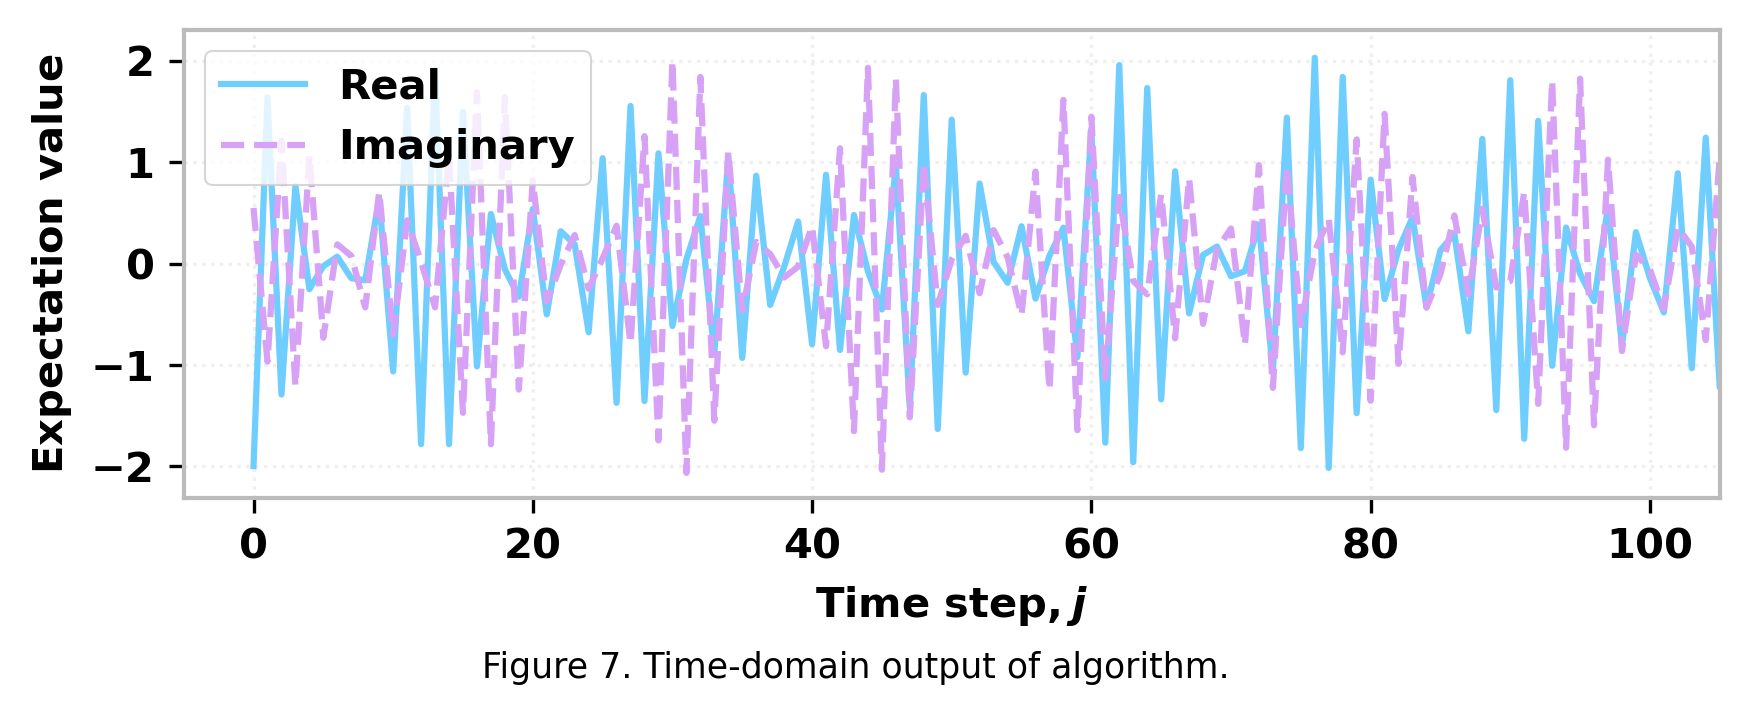

In [21]:
import matplotlib.pyplot as plt

plt.style.use("pennylane.drawer.plot")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(6.4, 2.4))
ax = fig.add_axes((0.15, 0.3, 0.8, 0.65))  # Leave space for caption.
ax.plot(range(len(expvals[0, :])), expvals[0, :], 
        label="Real", color=colors[0])
ax.plot(range(len(expvals[1, :])), expvals[1, :], 
        label="Imaginary", linestyle="--", color=colors[3])
ax.set(xlabel=r"$\mathrm{Time\ step}, j$", 
       ylabel=r"$\mathrm{Expectation\ value}$",
       xlim=[-5, 105],
      )
fig.text(0.5, 0.05,
    "Figure 7. Time-domain output of algorithm.",
    horizontalalignment="center",
    size="small", weight="normal")
ax.legend()
plt.show()

From the plot above, we can see a [beat
note](https://en.wikipedia.org/wiki/Beat_(acoustics)), indicating there
are two strong frequencies in our spectrum.

To calculate the Fourier transform of the time-domain Green's function,
we can use an expression where the real and imaginary components of the
expectation values are separate, since we have them stored in different
arrays.

$$-\mathrm{Im}\,G(\omega) = \frac{\eta\tau}{2\pi}\left(1 + 2\sum_{j=1}^{j_\mathrm{max}}e^{-\eta \tau j}\left[ \mathbb{E}\left(\mathrm{Re}\,\tilde G(\tau j)\right)\mathrm{cos}(\tau j \omega) - \mathbb{E}\left(\mathrm{Im}\,\tilde G(\tau j)\right) \mathrm{sin}(\tau j \omega)\right]\right) \,,$$

where $\mathbb{E}$ is the expectation value. We calculate this below,
but also multiply the normalization factors over to the right side.


In [22]:
L_js = L_j(time_interval)

f_domain_Greens_func = (
    lambda w: tau/(2*np.pi) * (np.sum(np.array(dipole_norm)**2) 
            + 2*np.sum(L_js * (expvals[0, :] * np.cos(time_interval * w)
            - expvals[1, :] * np.sin(time_interval * w)))))

wgrid = np.linspace(-108, -104, 10000)  # Frequency array for plotting.
w_min, w_step = wgrid[0], wgrid[1] - wgrid[0]

spectrum = np.array([f_domain_Greens_func(w) for w in wgrid])

Since our chosen active space for $\mathrm{N}_2$ is small, we can easily
calculate a classical spectrum for comparison. We will need the final
state energies and the overlaps. These can be computed with PySCF, by
reusing the `mycasci` instance we created earlier. By increasing the
number of roots in the `fcisolver` and rerunning the instance, we can
obtain the energies of the excited final states. We can also calculate
the transition density matrix in the molecular orbital basis between the
final states and the initial state, $\langle F| \hat m_\rho |I \rangle$.


In [23]:
# Use CASCI to solve for excited states.
mycasci.fcisolver.nroots = 100  # Compute the first 100 states (or less).
mycasci.run(verbose=0)
energies = mycasci.e_tot

# Ground state energy.
E_i = mycasci.e_tot[0]

# Determine the dipole integrals using atomic orbitals.
dip_ints_ao = hf.mol.intor("int1e_r_cart", comp=3)
mo_coeffs = coeffs[:, n_core : n_core + n_cas]

# Convert to molecular orbital basis.
dip_ints_mo = qml.math.einsum("ik,xkl,lj->xij", mo_coeffs.T, dip_ints_ao, mo_coeffs)


def final_state_overlap(ci_id):
    # Transition density matrix in molecular orbital basis.
    t_dm1 = mycasci.fcisolver.trans_rdm1(
        mycasci.ci[0], mycasci.ci[ci_id], n_cas, n_electron_cas
    )
    # Transition dipole moments.
    return qml.math.einsum("xij,ji->x", dip_ints_mo, t_dm1)


# Compute overlaps.
F_m_Is = np.array([final_state_overlap(i) for i in range(len(energies))])

With the energies and the overlaps, we can compute the absorption cross
section directly from the formula in the introduction.


In [24]:
spectrum_classical_func = lambda E: (1 / np.pi) * np.sum(
                [np.sum(np.abs(F_m_I)**2) * eta / ((E - e)**2 + eta**2)
                    for (F_m_I, e) in zip(F_m_Is, energies)])

spectrum_classical = np.array([spectrum_classical_func(w) for w in wgrid])

Let's plot and compare the classical and quantum spectra.


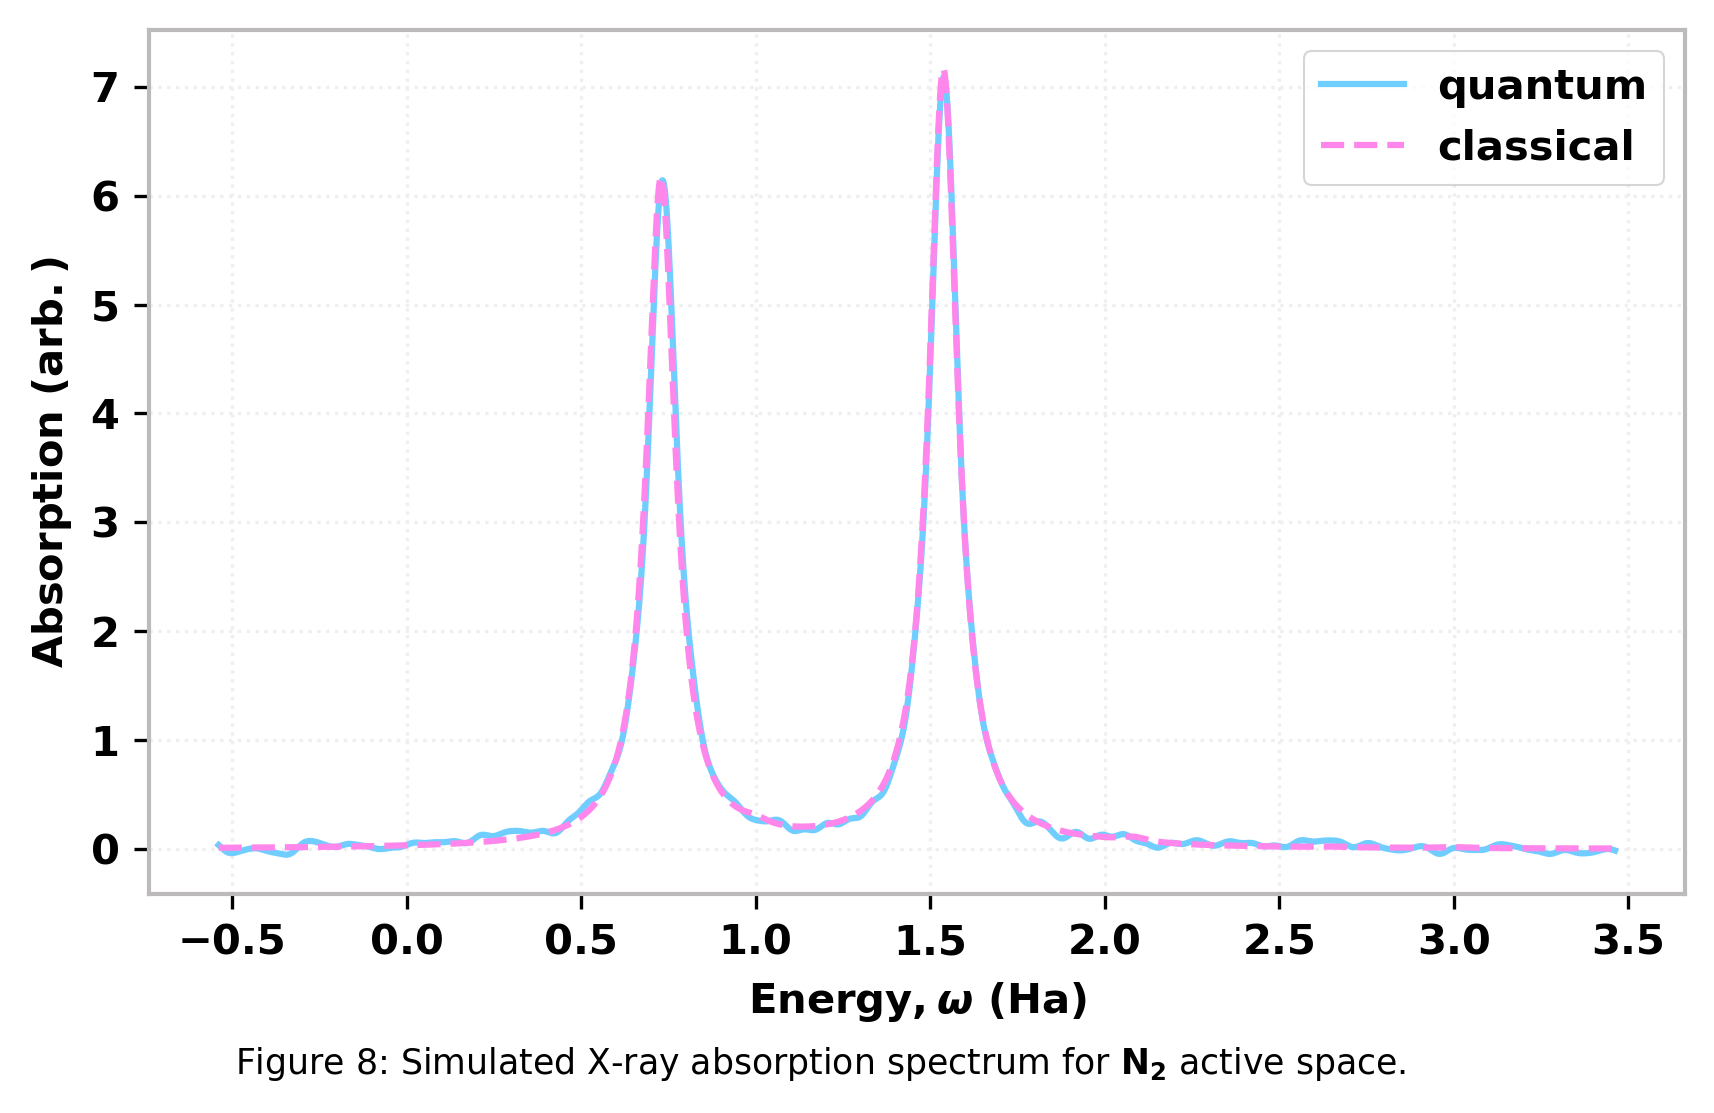

In [25]:
fig = plt.figure(figsize=(6.4, 4))
ax = fig.add_axes((0.15, 0.20, 0.80, 0.72))  # Make room for caption.

ax.plot(wgrid - E_i, spectrum, label="quantum")
ax.plot(wgrid - E_i, spectrum_classical, "--", label="classical")
ax.set_xlabel(r"$\mathrm{Energy}, \omega\ (\mathrm{Ha})$")
ax.set_ylabel(r"$\mathrm{Absorption\ (arb.)}$")
ax.legend()
fig.text(0.5, 0.05,
    r"Figure 8: Simulated X-ray absorption spectrum for $\mathrm{N}_2$ active space.",
    horizontalalignment="center",
    size="small", weight="normal")
plt.show()

Nice! We find our time-domain simulation method exactly reproduces the
classical spectrum \-- all that hard work paid off! Looking closely, we
can see there are two strong peaks, as predicted from the beat note in
the expectation values in Figure 7. If we worked with a larger active
space, we would obtain more features in the spectrum. The spectrum
calculated from the full orbital space is shown in Section V in
Ref.[^1].

# Conclusion

The XAS spectroscopy algorithm for studying battery materials is some of
the closest we\'ve been able to get to an industrially meaningful
application of fault-tolerant quantum computers. The ultralocal physics
of X-ray absorption allow us to focus on simulating relatively small
clusters and active spaces, significantly reducing qubit and gate
requirements relative to ground-state energy estimation. At the same
time, the observable we target \-- the absorption spectrum \-- remains
classically hard. In this tutorial, we have implemented a simplified
version of the algorithm as presented in Ref.[^2]. The algorithm
represents a culmination of many optimizations for time-evolving an
electronic Hamiltonian, leveraging product formulas to achieve a very
small qubit footprint. Thanks to this, we\'re even able to simulate it
classically! We hope that when fault tolerant hardware reaches maturity,
this implementation might even form the basis for the quantum program we
will write to simulate advanced battery cathodes.

Appendix: Further optimizations
\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\--

There are more optimizations for this algorithm that are included in
Ref.[^3] that we did not implement in the above code. One could further
optimize the compressed double-factorized Hamiltonian by applying a
block-invariant symmetry shift (BLISS)[^4] to the Hamiltonian prior to
the factorization. This is already detailed in the [demo on CDF
Hamiltonians](demos/tutorial_how_to_build_compressed_double_factorized_hamiltonians).

Another optimization is to use a randomized second-order Trotter formula
for the time evolution. As discussed in Ref.[^5], the errors in
deterministic product formulas scale with the number of commutators of
the Hamiltonian terms. One could instead randomly permute the
Hamiltonian term orderings between different Trotter steps, such that
many of the commutator error terms cancel.

## Core-valence separation approximation

For larger molecular instances, a simplifying approximation is to
restrict the excited states in the calculation to only include those of
relevance for XAS, which are states where a *core* electron is excited,
i.e. there exists a hole in the core orbitals. These are known as
core-excited states, and lie significantly above the valence-excited
states in energy. Typically the frequency range is focused on a target
atom in a molecular cluster, and also near a transition energy, such as
targeting core $1s$ electrons.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_xas/main/_assets/images/core_valence.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 9: <em>Core-valence separation.</em> A much larger
amount of energy is required to excite core electrons into valence
orbitals compared to electrons already in low-lying valence
orbitals.</figcaption>
</figure>

To make the restriction to core-excited states in practice, we need to
turn off the two-electron terms that couple core-excited and
valence-excited states. These terms are in general small, but by setting
them to zero the coupling is removed entirely from the time evolution.
To implement the core-valence separation approximation in an XAS
simulation algorithm, there are two steps:

-   Before performing compressed double factorization on the
    two-electron integrals, remove from the two-electron integrals the
    terms that include at least one core orbital and at least one
    valence orbital. This decouples the core-excited and valence-excited
    state manifolds.
-   Remove all the matrix elements from the dipole operator that do
    *not* include exactly one core orbital. This allows the quantum
    algorithm to start directly in the core-excited state manifold.

This approximation would be useful when simulating a complex molecular
instance, such as a cluster in a lithium-excess material.

[^1]: Stepan Fomichev, Pablo A. M. Casares, Jay Soni, Utkarsh Azad,
    Alexander Kunitsa, Arne-Christian Voigt, Jonathan E. Mueller, and
    Juan Miguel Arrazola, "Fast simulations of X-ray absorption
    spectroscopy for battery materials on a quantum computer". [arXiv
    preprint arXiv:2506.15784 (2025)](https://arxiv.org/abs/2506.15784).

[^2]: Stepan Fomichev, Pablo A. M. Casares, Jay Soni, Utkarsh Azad,
    Alexander Kunitsa, Arne-Christian Voigt, Jonathan E. Mueller, and
    Juan Miguel Arrazola, "Fast simulations of X-ray absorption
    spectroscopy for battery materials on a quantum computer". [arXiv
    preprint arXiv:2506.15784 (2025)](https://arxiv.org/abs/2506.15784).

[^3]: Stepan Fomichev, Pablo A. M. Casares, Jay Soni, Utkarsh Azad,
    Alexander Kunitsa, Arne-Christian Voigt, Jonathan E. Mueller, and
    Juan Miguel Arrazola, "Fast simulations of X-ray absorption
    spectroscopy for battery materials on a quantum computer". [arXiv
    preprint arXiv:2506.15784 (2025)](https://arxiv.org/abs/2506.15784).

[^4]: Ignacio Loaiza and Artur F Izmaylov, "Block-invariant symmetry
    shift: Preprocessing technique for second-quantized Hamiltonians to
    improve their decompositions to linear combination of unitaries".
    [J. Chem. Theory Comput. 19, 22, 8201--8209
    (2023)](https://doi.org/10.1021/acs.jctc.3c00912).

[^5]: Andrew M. Childs, Aaron Ostrander, and Yuan Su, "Faster quantum
    simulation by randomization". [Quantum 3, 182
    (2019)](https://doi.org/10.22331/q-2019-09-02-182).
